<h2 align="center" style="color:purple">Phase 2: AtliQ0 Bank Credit Card Project</h2>

### Business Analysis and Launch of A/B Testing: Targeting an Untapped Market

### Insights for Customers Aged 18–25

1. Customers in the **18–25 age group represent approximately 25% of the total customer base** in the dataset.

2. The **average annual income of this segment is below $50,000**, indicating relatively lower purchasing power compared to older age groups.

3. Individuals in this age group generally **have limited credit history**, which is reflected in **lower credit scores and lower maximum credit limits**.

4. The **usage of credit cards as a payment method is relatively lower** for this group when compared with other age segments.

5. The **average transaction value made using credit cards is also lower** than that of other age groups.

6. The **top three most frequently purchased product categories** among this segment are:
   - Electronics  
   - Fashion and Apparel  
   - Beauty and Personal Care

<p align="center">
  <img src="analysis.png" width="600">
</p>

<p align="center">
  Figure: Analysis of customer behavior for the 18–25 segment
</p>

## (1) Pre-Campaign

Before launching the new credit card campaign, a pilot A/B test will be conducted to evaluate its effectiveness.

The first step is to determine **how many customers are required for the A/B test**. The experiment will consist of two groups:

- **Control Group** – customers who will not receive the new campaign.
- **Test Group** – customers who will receive the new credit card offer.

The **sample size for each group** will be determined using statistical methods based on two key parameters agreed upon with the business team:

- **Statistical Power** – the probability of correctly detecting a real effect.
- **Effect Size** – the expected impact of the campaign on customer behavior.

Using these inputs, we will calculate the **minimum number of customers required in both the control and test groups** to ensure the experiment produces statistically reliable results.

In [6]:
#import required libraries
import statsmodels.stats.api as sms
import statsmodels.api as sm
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
alpha=0.05
power=0.8
effect_size=0.2
sms.tt_ind_solve_power(
    effect_size=effect_size, 
    alpha=alpha, 
    power=power, 
    ratio=1, 
    alternative='two-sided'
)

393.40569300025135

In [12]:
effect_sizes=[0.1,0.2,0.3,0.4,0.5,1]
for effect_size in effect_sizes:
    sample_size=sms.tt_ind_solve_power(
        effect_size=effect_size, 
        alpha=alpha, 
        power=power, 
        ratio=1, 
        alternative='two-sided'
    )
    print(f"effect size:{effect_size},Required Sample Size: {sample_size:.0f} customers")

effect size:0.1,Required Sample Size: 1571 customers
effect size:0.2,Required Sample Size: 393 customers
effect size:0.3,Required Sample Size: 175 customers
effect size:0.4,Required Sample Size: 99 customers
effect size:0.5,Required Sample Size: 64 customers
effect size:1,Required Sample Size: 17 customers


Based on business requirements, the test should be capable of detecting a minimum 0.4 standard deviation difference between the control and test groups. For the effect size 0.4, we need 100 customers and when we discussed with business, 100 customers is ok in terms of their budgeting constraints for this trail run

#### Forming Control and Test Groups

1. Approximately **246 customers** were identified within the **18–25 age group**. From this pool, **100 customers were selected** for the initial campaign launch.

2. The campaign was launched to these **100 selected customers**, based on the **sample size estimation and budget constraints**, and was conducted over a **period of two months**.

3. The campaign achieved a **conversion rate of approximately 40%**, meaning **40 out of the 100 customers** in the test group began using the credit card.

4. To create a fair comparison, a **control group of 40 customers** was formed. These customers were **completely separate from the initial 100 customers** who received the campaign.

5. As a result, the final setup consists of **40 customers in the test group (those who converted)** and **40 customers in the control group**, enabling a balanced comparison for further analysis.

##### At the end of the 2-month campaign period (09-10-23 to 11-10-23), daily data was collected capturing the **average transaction amounts** made by the 40 customers in both the **control group** and the **test group**. The control group used the **existing credit card**, while the test group used the **newly launched credit card**.

##### The primary **Key Performance Indicator (KPI)** for this A/B test is to determine whether the **new credit card increases the average transaction amount** compared to the existing card.

## (2) Post-Campaign

## Two Sample Z Test for Our Hypothesis Testing

In [14]:
df = pd.read_csv('data/avg_transactions_after_campaign.csv')
df.head(4)

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,259.83,277.32
1,2023-09-11,191.27,248.68
2,2023-09-12,212.41,286.61
3,2023-09-13,214.92,214.85


In [15]:
df.shape

(62, 3)

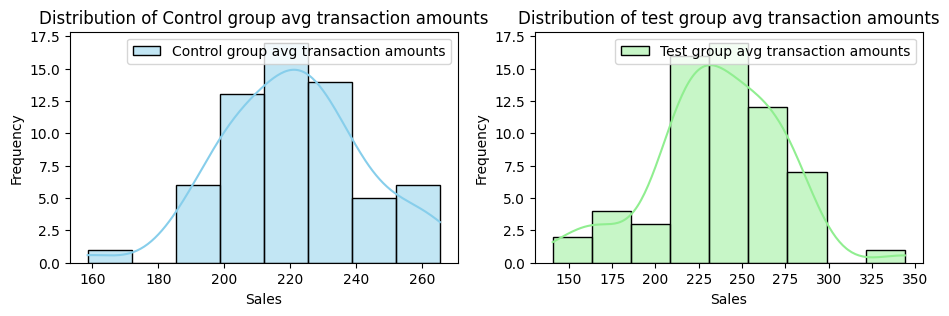

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

# Plot the distribution of Campaign A Sales
sns.histplot(df['control_group_avg_tran'], kde=True, color='skyblue', label='Control group avg transaction amounts', ax=ax1)
ax1.set_xlabel('Sales')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Control group avg transaction amounts')
ax1.legend()

# Plot the distribution of Campaign B Sales
sns.histplot(df['test_group_avg_tran'], kde=True, color='lightgreen', label='Test group avg transaction amounts', ax=ax2)
ax2.set_xlabel('Sales')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of test group avg transaction amounts')
ax2.legend()

# Show the plots
plt.show()

In [17]:
df[df["control_group_avg_tran"]> df["test_group_avg_tran"]]

,campaign_date,control_group_avg_tran,test_group_avg_tran
3,2023-09-13,214.92,214.85
8,2023-09-18,265.13,212.60
9,2023-09-19,232.88,207.63
16,2023-09-26,222.95,213.30
22,2023-10-02,238.39,203.10
23,2023-10-03,253.95,234.26
25,2023-10-05,239.47,216.37
26,2023-10-06,200.70,166.70
27,2023-10-07,200.91,170.01
28,2023-10-08,188.30,150.27


In [18]:
df[df["control_group_avg_tran"]> df["test_group_avg_tran"]].shape

(18, 3)

In [19]:
df[df["control_group_avg_tran"]> df["test_group_avg_tran"]].shape[0]/df.shape[0]

0.2903225806451613

In [20]:
(df[df["control_group_avg_tran"]> df["test_group_avg_tran"]].shape[0]/df.shape[0])*100

29.03225806451613

In [22]:
control_mean=df.control_group_avg_tran.mean()
control_std=df.control_group_avg_tran.std()
control_mean, control_std

(np.float64(221.1751612903226), np.float64(21.35919211202701))

In [23]:
test_mean=df.test_group_avg_tran.mean()
test_std=df.test_group_avg_tran.std()
test_mean, test_std

(np.float64(235.9835483870968), np.float64(36.658082109186374))

In [24]:
sample_size=df.shape[0]
sample_size

62

### Test Using Rejection Region (i.e. Critical Z Value)

In [26]:
a=control_std**2/sample_size
b=test_std**2/sample_size

In [27]:
z_score=(test_mean-control_mean)/np.sqrt(a+b)
z_score

np.float64(2.748297374569113)

In [28]:
z_critical=st.norm.ppf(1-alpha)
z_critical

np.float64(1.6448536269514722)

In [29]:
z_score>z_critical

np.True_

Since Z score is higher than critical Z value, we can reject the null hypothesis.

### Test Using p-Value

In [30]:
p_value=1-st.norm.cdf(z_score)

In [31]:
p_value

np.float64(0.0029952824622024865)

In [32]:
p_value<alpha

np.True_

Since p value is less than significance level (i.e. alpha), we can reject the null hypothesis.

### Using Ready Made API call

1. We will use the **stats module from the statsmodels library** to perform the Z-test.

2. The **order in which the control and test group data are passed** to  
   `sm.stats.ztest(test_data, control_data)` determines the **direction of the test** and influences how the result is interpreted.

3. When the **test group data is passed first**, the Z-test assumes the **alternative hypothesis that the mean of the test group is greater than the mean of the control group**.  
   Conversely, if the order is reversed, the test assumes that the **control group mean is greater than the test group mean**.

4. In this case, we will use the order  
   `sm.stats.ztest(test_group_data, control_group_data)`  
   because our **alternative hypothesis states that the test group should have a higher average transaction amount than the control group**.

5. By default, the **Z-test in statsmodels performs a two-tailed test**. Since our hypothesis is **directional**, we need to specify the `alternative` parameter.

6. Based on our hypothesis, we set the **`alternative` parameter to `"larger"`**, indicating that we are testing whether the **mean of the first group (test group) is greater than the second group (control group)**.

#### Choosing the Correct `alternative` Parameter

- **two-sided**  
  Used when we want to detect **any difference between the two groups**, regardless of direction.

- **larger**  
  A **one-tailed test** used to check whether the **first group has a significantly larger mean than the second group**.

- **smaller**  
  A **one-tailed test** used to check whether the **first group has a significantly smaller mean than the second group**.

![image.png](image.png)

For more details about the Z-test function and its parameters, refer to the official documentation:  
https://statsmodels.org/devel/generated/statsmodels.stats.weightstats.ztest.html

In [33]:
# Performing Z-test with above considerations
z_statistic, p_value = sm.stats.ztest( df['test_group_avg_tran'],df['control_group_avg_tran'],alternative = 'larger')
z_statistic, p_value

(np.float64(2.7482973745691135), np.float64(0.002995282462202502))